In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("../data/healthcare_doctor_visits.csv")

In [9]:
#top 5 rows
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [10]:
#last 5 rows
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [11]:
df.shape

(5190, 13)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   str    
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   str    
 9   freepoor    5190 non-null   str    
 10  freerepat   5190 non-null   str    
 11  nchronic    5190 non-null   str    
 12  lchronic    5190 non-null   str    
dtypes: float64(2), int64(5), str(6)
memory usage: 527.2 KB


In [13]:
#stastical inforamation of the dataset
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [14]:
#Checking the null values
df.isnull().sum()

Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64

### Univariate Analysis: Gender Distribution

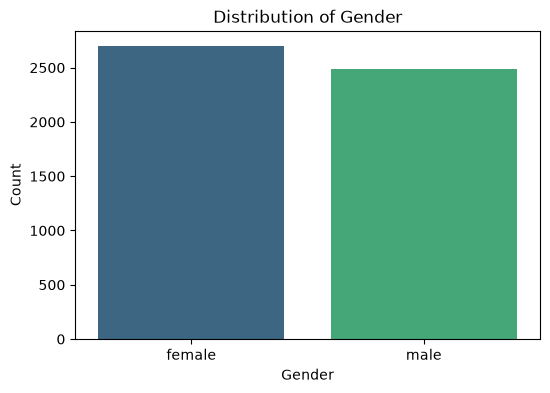

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df, palette='viridis', hue='gender', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Univariate Analysis: Age Distribution

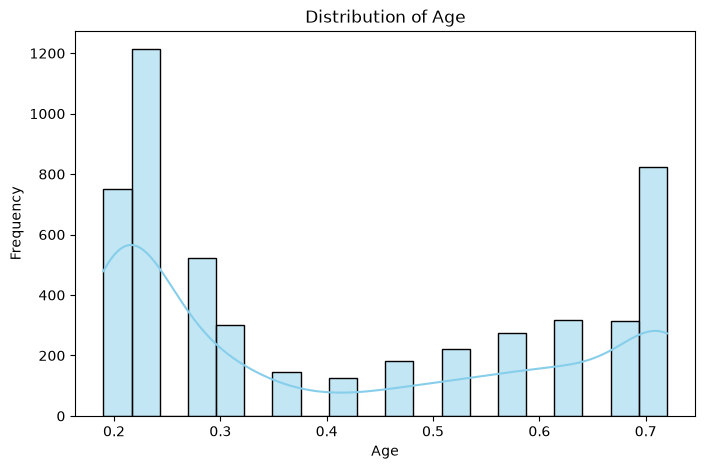

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Univariate Analysis: Doctor Visits Distribution

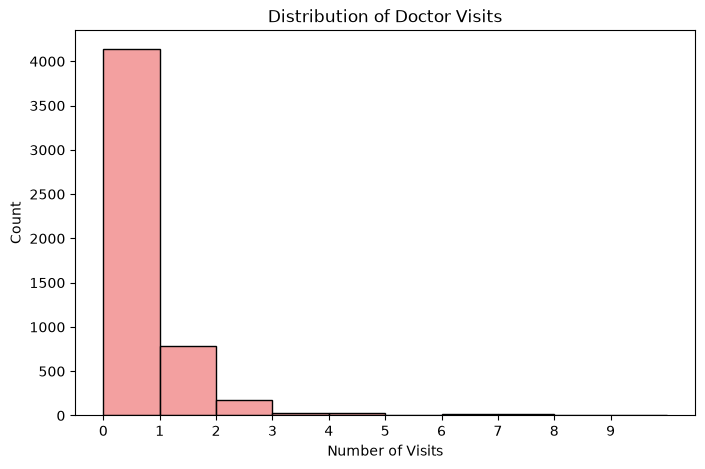

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df['visits'], bins=range(int(df['visits'].max()) + 2), kde=False, color='lightcoral', stat='count')
plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Count')
plt.xticks(range(int(df['visits'].max()) + 1))
plt.show()

,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


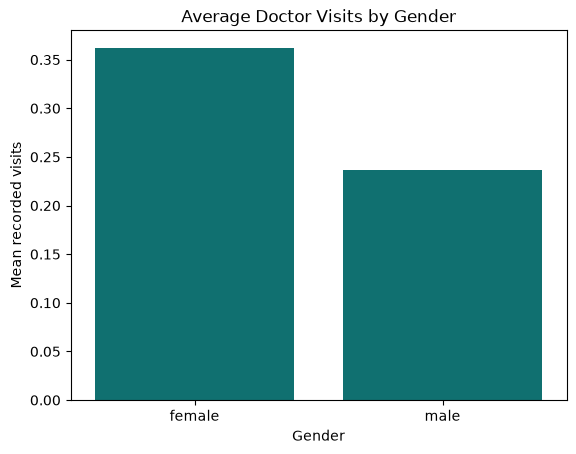

In [18]:
gender_analysis = (
    df.groupby("gender")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

display(gender_analysis)

sns.barplot(
    data=gender_analysis,
    x="gender",
    y="mean",
    color="teal"
)

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean recorded visits")
plt.show()

,illness,count,mean
0,0,1554,0.078507
1,1,1638,0.295482
2,2,946,0.403805
3,3,542,0.420664
4,4,274,0.576642
5,5,236,0.813559


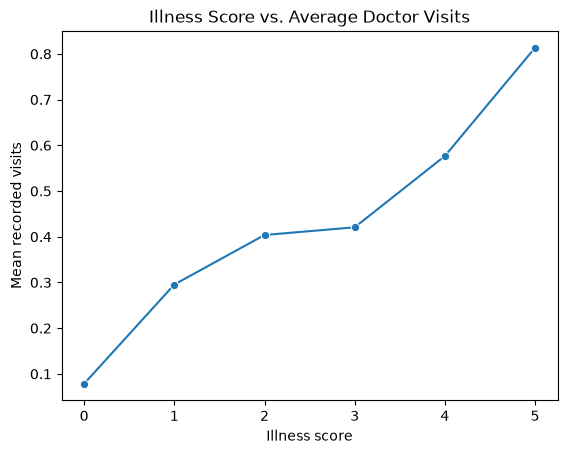

In [19]:
illness_analysis = (
    df.groupby("illness")["visits"]
      .agg(["count", "mean"])
      .reset_index()
)

display(illness_analysis)

sns.lineplot(
    data=illness_analysis,
    x="illness",
    y="mean",
    marker="o"
)

plt.title("Illness Score vs. Average Doctor Visits")
plt.xlabel("Illness score")
plt.ylabel("Mean recorded visits")
plt.show()

### Multivariate Analysis: Visits by Gender

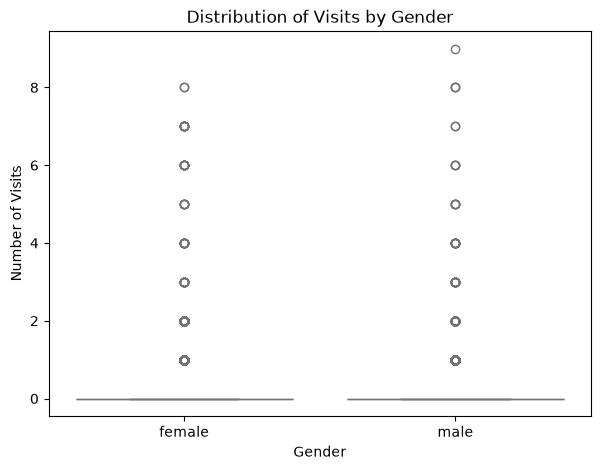

In [20]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='gender', y='visits', data=df, palette='pastel', hue='gender', legend=False)
plt.title('Distribution of Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Visits')
plt.show()

### Multivariate Analysis: Age, Visits, and Gender

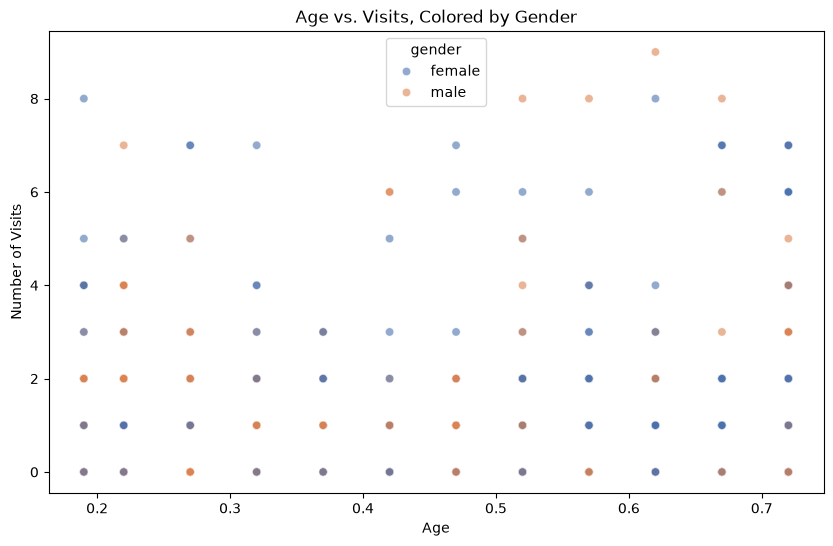

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='visits', hue='gender', data=df, palette='deep', alpha=0.6)
plt.title('Age vs. Visits, Colored by Gender')
plt.xlabel('Age')
plt.ylabel('Number of Visits')
plt.show()

Correlation Analysis

In [22]:
# Correlation Analysis

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

display(correlation)

,Unnamed: 0,visits,age,income,illness,reduced,health
Unnamed: 0,1.000000,-0.521645,-0.016322,0.074632,-0.290047,-0.245314,-0.194966
visits,-0.521645,1.000000,0.124537,-0.076840,0.223552,0.418954,0.193272
age,-0.016322,0.124537,1.000000,-0.271073,0.204984,0.094745,0.018616
income,0.074632,-0.076840,-0.271073,1.000000,-0.148812,-0.047545,-0.085790
illness,-0.290047,0.223552,0.204984,-0.148812,1.000000,0.218116,0.360110
reduced,-0.245314,0.418954,0.094745,-0.047545,0.218116,1.000000,0.280208
health,-0.194966,0.193272,0.018616,-0.085790,0.360110,0.280208,1.000000


Correlation Heatmap


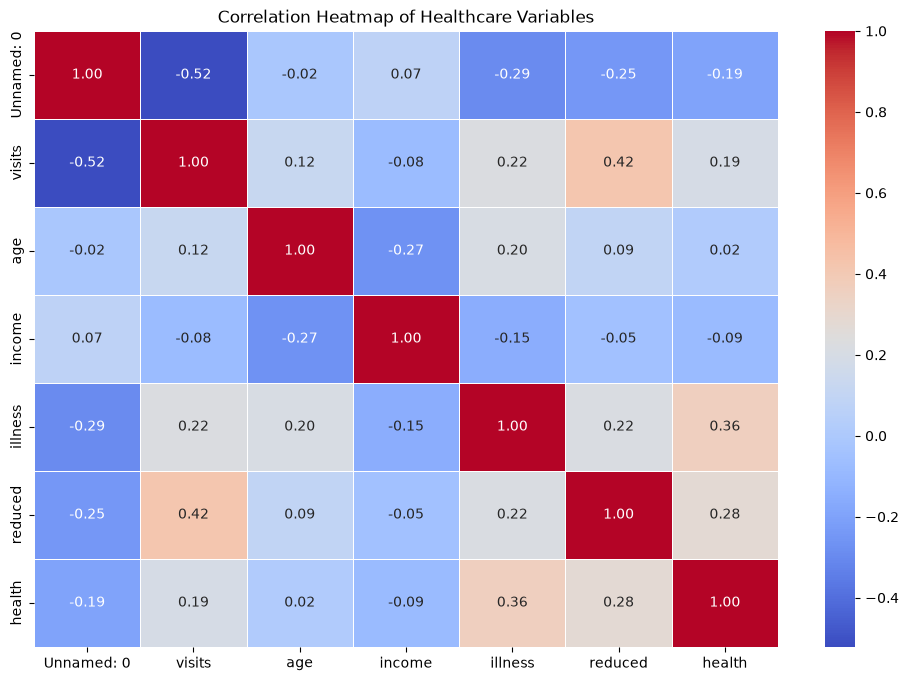

In [23]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Healthcare Variables')
plt.show()

Age Groups


In [24]:
# Creating Age Groups

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20', '21-40', '41-60', '61-80', '81-100']
)

df[['age', 'age_group']].head()

,age,age_group
0,0.19,0-20
1,0.19,0-20
2,0.19,0-20
3,0.19,0-20
4,0.19,0-20


Average Visits by Age Group

In [25]:
# Average Doctor Visits by Age Group

age_analysis = (
    df.groupby('age_group', observed=False)['visits']
      .agg(['count', 'mean', 'median'])
      .reset_index()
)

display(age_analysis)

,age_group,count,mean,median
0,0-20,5190,0.301734,0.0
1,21-40,0,NaN,NaN
2,41-60,0,NaN,NaN
3,61-80,0,NaN,NaN
4,81-100,0,NaN,NaN


Age Group Visualization

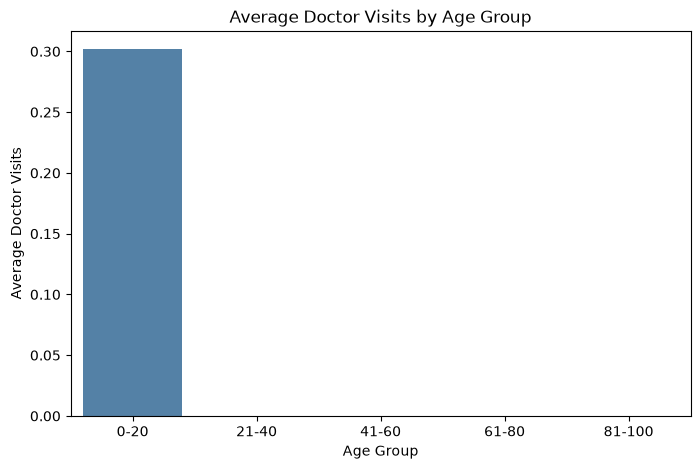

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=age_analysis,
    x='age_group',
    y='mean',
    color='steelblue'
)

plt.title('Average Doctor Visits by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Doctor Visits')
plt.show()

Illness Distribution

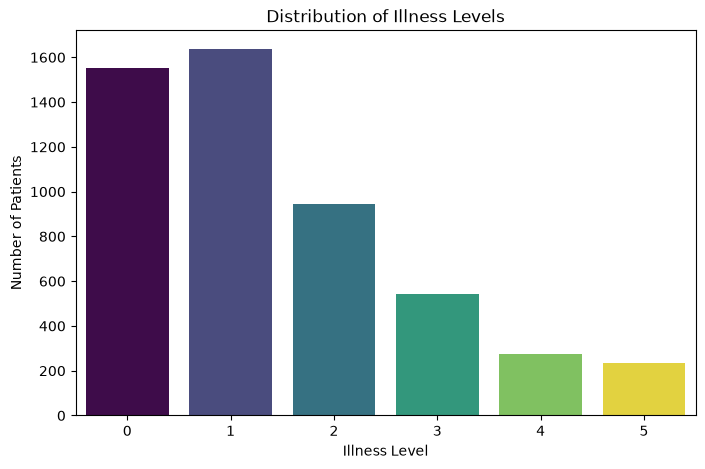

In [27]:
# Distribution of Illness

plt.figure(figsize=(8, 5))

sns.countplot(
    x='illness',
    data=df,
    hue='illness',
    palette='viridis',
    legend=False
)

plt.title('Distribution of Illness Levels')
plt.xlabel('Illness Level')
plt.ylabel('Number of Patients')
plt.show()

Chronic Conditions Analysis

In [28]:
# Display columns related to chronic conditions

[column for column in df.columns if 'chronic' in column.lower()]

['nchronic', 'lchronic']

In [29]:
# Chronic Conditions vs Doctor Visits

chronic_analysis = (
    df.groupby('nchronic')['visits']
      .agg(['count', 'mean', 'median'])
      .reset_index()
)

display(chronic_analysis)

,nchronic,count,mean,median
0,no,3098,0.272111,0.0
1,yes,2092,0.345602,0.0


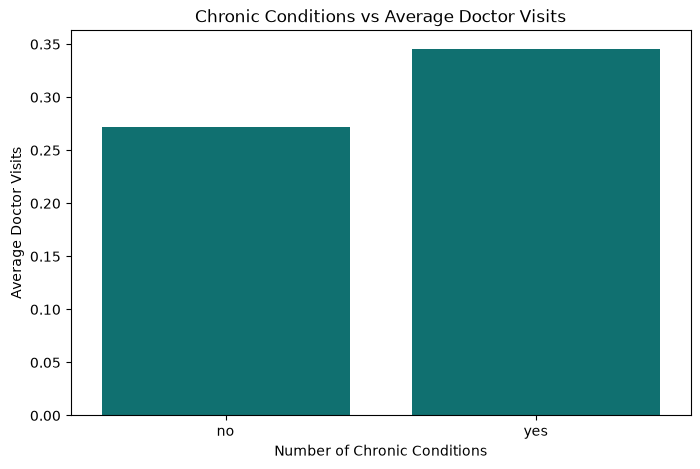

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=chronic_analysis,
    x='nchronic',
    y='mean',
    color='teal'
)

plt.title('Chronic Conditions vs Average Doctor Visits')
plt.xlabel('Number of Chronic Conditions')
plt.ylabel('Average Doctor Visits')
plt.show()

Health Status vs Doctor Visits

In [31]:
# Average Visits by Health Status

health_analysis = (
    df.groupby('health')['visits']
      .agg(['count', 'mean', 'median'])
      .reset_index()
)

display(health_analysis)

,health,count,mean,median
0,0,3026,0.199273,0.0
1,1,823,0.335358,0.0
2,2,446,0.381166,0.0
3,3,273,0.417582,0.0
4,4,187,0.534759,0.0
5,5,132,0.530303,0.0
6,6,104,0.625000,0.0
7,7,61,0.918033,0.0
8,8,42,0.476190,0.0
9,9,32,0.656250,0.0


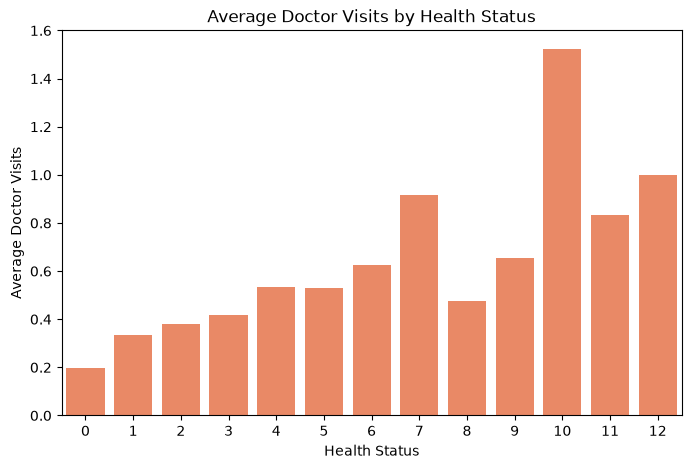

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=health_analysis,
    x='health',
    y='mean',
    color='coral'
)

plt.title('Average Doctor Visits by Health Status')
plt.xlabel('Health Status')
plt.ylabel('Average Doctor Visits')
plt.show()

Income vs Doctor Visits

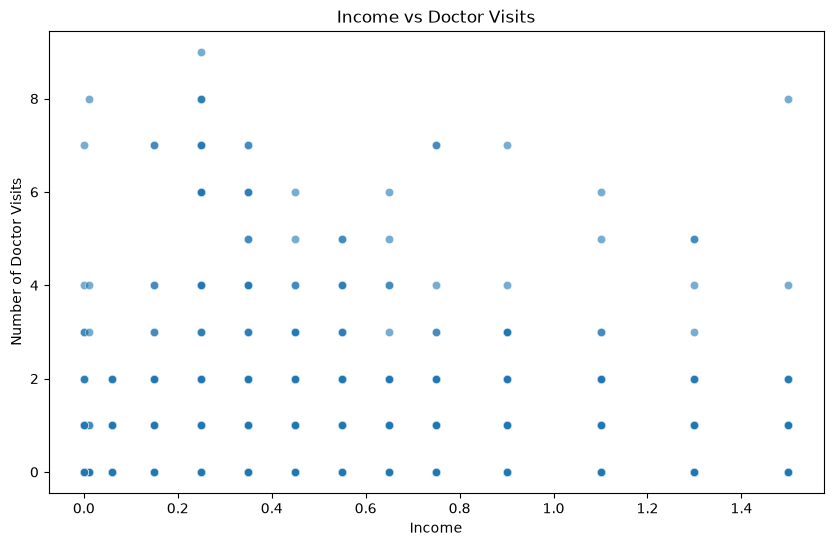

In [33]:
# Income vs Doctor Visits

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='income',
    y='visits',
    alpha=0.6
)

plt.title('Income vs Doctor Visits')
plt.xlabel('Income')
plt.ylabel('Number of Doctor Visits')
plt.show()

Summary Statistics of Doctor Visits

In [34]:
# Doctor Visit Summary

print("Total Patients:", len(df))
print("Average Doctor Visits:", df['visits'].mean())
print("Median Doctor Visits:", df['visits'].median())
print("Minimum Doctor Visits:", df['visits'].min())
print("Maximum Doctor Visits:", df['visits'].max())
print("Standard Deviation:", df['visits'].std())

Total Patients: 5190
Average Doctor Visits: 0.3017341040462428
Median Doctor Visits: 0.0
Minimum Doctor Visits: 0
Maximum Doctor Visits: 9
Standard Deviation: 0.79813383141369


Gender Summary

In [35]:
# Gender-wise Summary

gender_summary = df.groupby('gender')['visits'].agg(
    Patients='count',
    Average_Visits='mean',
    Median_Visits='median',
    Maximum_Visits='max'
).reset_index()

display(gender_summary)

,gender,Patients,Average_Visits,Median_Visits,Maximum_Visits
0,female,2702,0.361954,0.0,8
1,male,2488,0.236334,0.0,9


Overall Analysis Summary

In [36]:
# Overall Dataset Summary

summary = {
    'Total Records': len(df),
    'Total Columns': len(df.columns),
    'Average Doctor Visits': round(df['visits'].mean(), 2),
    'Median Doctor Visits': round(df['visits'].median(), 2),
    'Maximum Doctor Visits': df['visits'].max(),
    'Minimum Doctor Visits': df['visits'].min(),
    'Missing Values': df.isnull().sum().sum(),
    'Duplicate Records': df.duplicated().sum()
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=['Metric', 'Value']
)

display(summary_df)

,Metric,Value
0,Total Records,5190.0
1,Total Columns,14.0
2,Average Doctor Visits,0.3
3,Median Doctor Visits,0.0
4,Maximum Doctor Visits,9.0
5,Minimum Doctor Visits,0.0
6,Missing Values,0.0
7,Duplicate Records,0.0
